# **Практическая работа №11. Развёртывание модели классификации изображений на NVIDIA Triton Inference Server**

## **Цель работы**

Развернуть лучшую модель классификации изображений из практической работы №10 с использованием NVIDIA Triton Inference Server, создать API-шлюз на FastAPI, настроить мониторинг и провести нагрузочное тестирование с анализом влияния Dynamic Batching на производительность.

---

## **Раздел 1. Подготовка модели**

1. Загрузить лучшую модель из практической работы №10
2. Конвертировать модель в формат ONNX с помощью `tf2onnx` или `torch.onnx`
3. Проверить корректность конвертации (сравнить выходы оригинальной и ONNX-модели)
4. Сохранить препроцессор (scaler/normalizer) в формате `.pkl` **(При наличии)**

<details> <summary>Пример скрипта для конвертации</summary>

```python
import numpy as np
import tensorflow as tf
import tf2onnx
import onnxruntime as ort

# Загрузка модели классификации изображений
model = tf.keras.models.load_model("best_keras_model.h5", compile=False)

# Обёртка для инференса:
# - принимает батч изображений формы (N, 224, 224, 3)
# - применяет VGG16 preprocess_input
# - передаёт результат в модель
@tf.function(input_signature=[tf.TensorSpec((None, 224, 224, 3), tf.float32)])
def model_fn(x):
    x = tf.keras.applications.vgg16.preprocess_input(x)
    return model(x)

# Конвертация в ONNX
model_proto, _ = tf2onnx.convert.from_function(
    model_fn,
    input_signature=[tf.TensorSpec((None, 224, 224, 3), tf.float32)],
    opset=13,
    output_path="model.onnx"
)

# Тестовый инференс через ONNX Runtime
session = ort.InferenceSession("model.onnx")

# Пример: один тестовый RGB-кадр 224x224x3
# Если нужен батч, используйте shape (batch_size, 224, 224, 3)
test = np.random.randint(0, 256, (1, 224, 224, 3), dtype=np.uint8).astype(np.float32)

result = session.run(None, {session.get_inputs()[0].name: test})
pred = result[0]

print("✅ Сохранено: model.onnx")
print(f"\tФорма входа: {test.shape}")
print(f"\tФорма выхода: {pred.shape}")
print(f"\tPredicted class: {np.argmax(pred, axis=-1)}")
print(f"\tScores: {pred}")
```



In [ ]:
# Раздел 1. Подготовка модели: Keras -> ONNX + проверка

!pip install -q tf2onnx onnx onnxruntime pillow

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import numpy as np
import tensorflow as tf
import tf2onnx
import onnx
import onnxruntime as ort
from PIL import Image

# Пути в Google Drive
BASE_DIR = Path("/content/drive/MyDrive")
MODEL_PATH = BASE_DIR / "ПР-10" / "best_classification_model.keras"
META_PATH = BASE_DIR / "ПР-10" / "model_meta.json"
TEST_IMAGES_DIR = BASE_DIR / "ПР-3" / "birds_test"

OUT_DIR = BASE_DIR / "ПР-11"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ONNX_PATH = OUT_DIR / "model.onnx"
CLASSES_PATH = OUT_DIR / "class_names.json"

# Значения по умолчанию из практической работы №10
DEFAULT_CLASS_NAMES = [
    "Asian Green Bee-Eater",
    "Brown-Headed Barbet",
    "Common Kingfisher",
]
DEFAULT_IMG_SIZE = 128

# Если в ПР-10 есть model_meta.json, берём классы и размер изображения оттуда
if META_PATH.exists():
    with open(META_PATH, "r", encoding="utf-8") as f:
        meta = json.load(f)
    CLASS_NAMES = meta.get("class_names", DEFAULT_CLASS_NAMES)
    IMG_SIZE = int(meta.get("img_size", DEFAULT_IMG_SIZE))
else:
    CLASS_NAMES = DEFAULT_CLASS_NAMES
    IMG_SIZE = DEFAULT_IMG_SIZE

print("Классы:", CLASS_NAMES)
print("Размер изображения:", IMG_SIZE)

# Загрузка модели из ПР-10
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

print("Модель загружена")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

# Уточняем размер входа по самой модели
if model.input_shape[1] is not None:
    IMG_SIZE = int(model.input_shape[1])

# Модель обучалась на RGB-изображениях, приведённых к [0, 1]
input_signature = [
    tf.TensorSpec(
        shape=(None, IMG_SIZE, IMG_SIZE, 3),
        dtype=tf.float32,
        name="input_image",
    )
]

@tf.function(input_signature=input_signature)
def model_fn(x):
    return model(x, training=False)

# Конвертация Keras/TensorFlow -> ONNX
model_proto, _ = tf2onnx.convert.from_function(
    model_fn,
    input_signature=input_signature,
    opset=13,
    output_path=str(ONNX_PATH),
)

# Проверка корректности ONNX-файла
onnx_model = onnx.load(str(ONNX_PATH))
onnx.checker.check_model(onnx_model)

# Сохраняем классы отдельно: файл понадобится FastAPI Gateway
with open(CLASSES_PATH, "w", encoding="utf-8") as f:
    json.dump(CLASS_NAMES, f, ensure_ascii=False, indent=2)

print("ONNX-модель сохранена:", ONNX_PATH)
print("Файл классов сохранён:", CLASSES_PATH)

# Препроцессинг должен совпадать с ПР-10: RGB, resize, float32, /255.0
def load_image(path):
    image = Image.open(path).convert("RGB")
    image = image.resize((IMG_SIZE, IMG_SIZE))
    array = np.asarray(image, dtype=np.float32) / 255.0
    return np.expand_dims(array, axis=0)

# Берём реальное тестовое изображение, если оно есть
image_extensions = ["*.jpg", "*.jpeg", "*.png"]
test_images = []
for pattern in image_extensions:
    test_images.extend(TEST_IMAGES_DIR.glob(pattern))
test_images = sorted(test_images)

if test_images:
    test_image_path = test_images[0]
    test_batch = load_image(test_image_path)
    print("Тестовое изображение:", test_image_path)
else:
    test_image_path = None
    test_batch = np.random.rand(1, IMG_SIZE, IMG_SIZE, 3).astype(np.float32)
    print("Тестовые изображения не найдены, использован случайный массив")

# Предсказание исходной Keras-модели
keras_pred = model(test_batch, training=False).numpy()

# Предсказание ONNX Runtime
session = ort.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name
onnx_pred = session.run(None, {input_name: test_batch.astype(np.float32)})[0]

keras_class_id = int(np.argmax(keras_pred, axis=1)[0])
onnx_class_id = int(np.argmax(onnx_pred, axis=1)[0])
max_abs_diff = float(np.max(np.abs(keras_pred - onnx_pred)))

print("\nПроверка корректности конвертации")
print("ONNX input name:", input_name)
print("ONNX output name:", output_name)
print("Keras predicted class:", CLASS_NAMES[keras_class_id])
print("ONNX predicted class:", CLASS_NAMES[onnx_class_id])
print("Keras scores:", keras_pred[0])
print("ONNX scores:", onnx_pred[0])
print("Max absolute difference:", max_abs_diff)

if keras_class_id == onnx_class_id:
    print("\nКонвертация выполнена корректно: классы Keras и ONNX совпадают")
else:
    print("\nВнимание: классы Keras и ONNX не совпали")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 99.0 MB/s eta 0:00:00
Mounted at /content/drive
Классы: ['Asian Green Bee-Eater', 'Brown-Headed Barbet', 'Common Kingfisher']
Размер изображения: 128
Модель загружена
Input shape: (None, 128, 128, 3)
Output shape: (None, 3)
ONNX-модель сохранена: /content/drive/MyDrive/ПР-11/model.onnx
Файл классов сохранён: /content/drive/MyDrive/ПР-11/class_names.json
Тестовые изображения не найдены, использован случайный массив

Проверка корректности конвертации
ONNX input name: input_image
ONNX output name: Identity:0
Keras predicted class: Brown-Headed Barbet
ONNX predicted class: Brown-Headed Barbet
Keras scores: [0.26672676 0.41097155 0.32230175]
ONNX scores: [0.26672676 0.4109715  0.32230175]
Max absolute difference: 5.960464477539063e-08

Конвертация выполнена корректно: классы K

---

## **Раздел 2. Создание структуры проекта**

1. Создать структуру проекта для Triton:

```
triton-classification/
├── docker-compose.yml
├── test_client.py
├── model_repository/
│   └── image_classifier/
│       ├── config.pbtxt
│       └── 1/
│           └── model.onnx
├── api/
│   ├── Dockerfile
│   ├── requirements.txt
│   └── main.py
├── prometheus/
│   └── prometheus.yml
└── grafana/
    └── provisioning/
        ├── datasources/
        │   └── datasources.yml
        └── dashboards/
            ├── dashboards.yml
            └── triton.json
```

2. Написать `config.pbtxt` для модели классификации изображений
3. Реализовать FastAPI Gateway с эндпоинтами:
   - `POST /predict` — классификация изображения (принимает файл или base64)
   - `GET /health` — проверка состояния сервисов
   - `GET /classes` — список классов модели
4. Настроить `docker-compose.yml` с сервисами: Triton, FastAPI, Prometheus, Grafana

In [ ]:
# Ваш код
# Раздел 2. Создание структуры проекта Triton/FastAPI/Prometheus/Grafana

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import shutil

BASE_DIR = Path("/content/drive/MyDrive")
WORK_DIR = BASE_DIR / "ПР-11"
PROJECT_DIR = WORK_DIR / "triton-classification"

ONNX_SOURCE = WORK_DIR / "model.onnx"
CLASSES_SOURCE = WORK_DIR / "class_names.json"

if not ONNX_SOURCE.exists():
    raise FileNotFoundError(
        f"Не найден файл {ONNX_SOURCE}. Сначала выполните Раздел 1 и создайте model.onnx"
    )

if not CLASSES_SOURCE.exists():
    raise FileNotFoundError(
        f"Не найден файл {CLASSES_SOURCE}. Сначала выполните Раздел 1 и создайте class_names.json"
    )

with open(CLASSES_SOURCE, "r", encoding="utf-8") as f:
    class_names = json.load(f)

# Структура проекта
paths = [
    PROJECT_DIR / "model_repository" / "image_classifier" / "1",
    PROJECT_DIR / "api",
    PROJECT_DIR / "prometheus",
    PROJECT_DIR / "grafana" / "provisioning" / "datasources",
    PROJECT_DIR / "grafana" / "provisioning" / "dashboards",
]

for path in paths:
    path.mkdir(parents=True, exist_ok=True)

# Копируем модель и классы в Triton Model Repository
shutil.copy2(ONNX_SOURCE, PROJECT_DIR / "model_repository" / "image_classifier" / "1" / "model.onnx")
shutil.copy2(CLASSES_SOURCE, PROJECT_DIR / "model_repository" / "image_classifier" / "class_names.json")

# config.pbtxt для ONNX-модели классификации изображений
# Имена input/output должны совпадать с выводом ONNX Runtime из Раздела 1.
config_pbtxt = '''name: "image_classifier"
backend: "onnxruntime"
max_batch_size: 32

input [
  {
    name: "input_image"
    data_type: TYPE_FP32
    dims: [128, 128, 3]
  }
]

output [
  {
    name: "Identity:0"
    data_type: TYPE_FP32
    dims: [3]
  }
]

# Dynamic Batching собирает несколько одиночных запросов в один батч.
dynamic_batching {
  preferred_batch_size: [4, 8, 16]
  max_queue_delay_microseconds: 100000
}

instance_group [
  {
    count: 1
    kind: KIND_CPU
  }
]
'''

(PROJECT_DIR / "model_repository" / "image_classifier" / "config.pbtxt").write_text(
    config_pbtxt,
    encoding="utf-8",
)

# Зависимости FastAPI Gateway
api_requirements = '''fastapi==0.115.6
uvicorn[standard]==0.34.0
numpy==1.26.4
pillow==11.1.0
python-multipart==0.0.20
tritonclient[grpc]==2.53.0
'''

(PROJECT_DIR / "api" / "requirements.txt").write_text(api_requirements, encoding="utf-8")

# Dockerfile для FastAPI Gateway
api_dockerfile = '''FROM python:3.10-slim

WORKDIR /app

RUN python -m pip install --upgrade pip
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY main.py .

EXPOSE 8080

CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8080"]
'''

(PROJECT_DIR / "api" / "Dockerfile").write_text(api_dockerfile, encoding="utf-8")

# FastAPI Gateway: принимает base64 или multipart-файл, делает препроцессинг и вызывает Triton по gRPC
api_main = r'''import base64
import io
import json
import os
import time
from typing import Any

import numpy as np
import tritonclient.grpc as grpcclient
from fastapi import FastAPI, HTTPException, Request
from PIL import Image
from tritonclient.utils import InferenceServerException

TRITON_URL = os.getenv("TRITON_URL", "triton:8001")
MODEL_NAME = os.getenv("MODEL_NAME", "image_classifier")
IMG_SIZE = int(os.getenv("IMG_SIZE", "128"))
CLASSES_PATH = os.getenv("CLASSES_PATH", "/models/image_classifier/class_names.json")

app = FastAPI(
    title="Image Classification Gateway",
    description="FastAPI gateway for NVIDIA Triton image classification model",
    version="1.0.0",
)

triton_client: grpcclient.InferenceServerClient | None = None
input_name: str | None = None
output_name: str | None = None
class_names: list[str] = []


def load_classes() -> list[str]:
    if not os.path.exists(CLASSES_PATH):
        raise RuntimeError(f"Classes file not found: {CLASSES_PATH}")
    with open(CLASSES_PATH, "r", encoding="utf-8") as f:
        return json.load(f)


def preprocess_image(image_bytes: bytes) -> np.ndarray:
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    image = image.resize((IMG_SIZE, IMG_SIZE))
    array = np.asarray(image, dtype=np.float32) / 255.0
    return array


def decode_base64_image(value: str) -> bytes:
    # Поддерживает обычный base64 и data URL вида data:image/png;base64,...
    if "," in value and value.strip().lower().startswith("data:"):
        value = value.split(",", 1)[1]
    return base64.b64decode(value)


async def read_images_from_request(request: Request) -> list[bytes]:
    content_type = request.headers.get("content-type", "")

    if "multipart/form-data" in content_type:
        form = await request.form()
        files = []
        if "file" in form:
            files.append(form["file"])
        files.extend(form.getlist("files"))
        if not files:
            raise HTTPException(status_code=400, detail="Upload file or files field is required")
        return [await file.read() for file in files]

    payload: dict[str, Any] = await request.json()
    if "image" in payload:
        return [decode_base64_image(payload["image"])]
    if "images" in payload:
        return [decode_base64_image(item) for item in payload["images"]]

    raise HTTPException(status_code=400, detail="JSON must contain image or images field")


def infer(batch: np.ndarray) -> np.ndarray:
    if triton_client is None or input_name is None or output_name is None:
        raise RuntimeError("Triton client is not initialized")

    infer_input = grpcclient.InferInput(input_name, batch.shape, "FP32")
    infer_input.set_data_from_numpy(batch.astype(np.float32))
    infer_output = grpcclient.InferRequestedOutput(output_name)

    response = triton_client.infer(
        model_name=MODEL_NAME,
        inputs=[infer_input],
        outputs=[infer_output],
    )
    result = response.as_numpy(output_name)
    if result is None:
        raise RuntimeError(f"Triton returned empty output: {output_name}")
    return result


@app.on_event("startup")
def startup() -> None:
    global triton_client, input_name, output_name, class_names

    class_names = load_classes()
    triton_client = grpcclient.InferenceServerClient(url=TRITON_URL, verbose=False)

    last_error: Exception | None = None
    for _ in range(30):
        try:
            if triton_client.is_server_live() and triton_client.is_model_ready(MODEL_NAME):
                metadata = triton_client.get_model_metadata(MODEL_NAME)
                input_name = metadata.inputs[0].name
                output_name = metadata.outputs[0].name
                return
        except Exception as exc:
            last_error = exc
        time.sleep(2)

    raise RuntimeError(f"Triton model is not ready: {last_error}")


@app.get("/")
def root() -> dict[str, Any]:
    return {
        "service": "Image Classification Gateway",
        "model": MODEL_NAME,
        "endpoints": ["GET /health", "GET /classes", "POST /predict"],
    }


@app.get("/health")
def health() -> dict[str, Any]:
    try:
        live = triton_client.is_server_live() if triton_client else False
        ready = triton_client.is_model_ready(MODEL_NAME) if triton_client else False
        return {
            "status": "healthy" if live and ready else "unhealthy",
            "triton_live": live,
            "model_ready": ready,
            "model_name": MODEL_NAME,
            "input_name": input_name,
            "output_name": output_name,
            "classes_loaded": len(class_names),
        }
    except InferenceServerException as exc:
        return {"status": "unhealthy", "error": str(exc)}


@app.get("/classes")
def classes() -> dict[str, Any]:
    return {"classes": class_names}


@app.post("/predict")
async def predict(request: Request) -> dict[str, Any]:
    try:
        raw_images = await read_images_from_request(request)
        batch = np.stack([preprocess_image(item) for item in raw_images]).astype(np.float32)

        start = time.perf_counter()
        scores = infer(batch)
        inference_ms = (time.perf_counter() - start) * 1000

        predictions = []
        for row in scores:
            class_id = int(np.argmax(row))
            predictions.append({
                "class_id": class_id,
                "class_name": class_names[class_id],
                "confidence": float(row[class_id]),
                "probabilities": {
                    class_name: float(probability)
                    for class_name, probability in zip(class_names, row)
                },
            })

        return {
            "model": MODEL_NAME,
            "batch_size": len(predictions),
            "inference_ms": round(inference_ms, 3),
            "predictions": predictions,
        }
    except HTTPException:
        raise
    except Exception as exc:
        raise HTTPException(status_code=500, detail=str(exc)) from exc
'''

(PROJECT_DIR / "api" / "main.py").write_text(api_main, encoding="utf-8")

# Docker Compose: Triton + FastAPI + Prometheus + Grafana
docker_compose = '''services:
  triton:
    image: nvcr.io/nvidia/tritonserver:24.01-py3
    platform: linux/amd64
    container_name: triton-server
    ports:
      - "8000:8000"
      - "8001:8001"
      - "8002:8002"
    volumes:
      - ./model_repository:/models:ro
    command: >
      tritonserver
      --model-repository=/models
      --strict-model-config=true
      --log-verbose=1
    healthcheck:
      test: ["CMD-SHELL", "curl -f http://localhost:8000/v2/health/ready || exit 1"]
      interval: 10s
      timeout: 5s
      retries: 12
      start_period: 30s

  api:
    build: ./api
    container_name: image-classifier-api
    ports:
      - "8080:8080"
    environment:
      TRITON_URL: triton:8001
      MODEL_NAME: image_classifier
      IMG_SIZE: 128
      CLASSES_PATH: /models/image_classifier/class_names.json
    volumes:
      - ./model_repository:/models:ro
    depends_on:
      triton:
        condition: service_healthy

  prometheus:
    image: prom/prometheus:latest
    container_name: prometheus
    ports:
      - "9090:9090"
    volumes:
      - ./prometheus/prometheus.yml:/etc/prometheus/prometheus.yml:ro
      - prometheus_data:/prometheus
    depends_on:
      - triton

  grafana:
    image: grafana/grafana:latest
    container_name: grafana
    ports:
      - "3000:3000"
    environment:
      GF_SECURITY_ADMIN_USER: admin
      GF_SECURITY_ADMIN_PASSWORD: admin
      GF_USERS_ALLOW_SIGN_UP: "false"
    volumes:
      - grafana_data:/var/lib/grafana
      - ./grafana/provisioning:/etc/grafana/provisioning:ro
    depends_on:
      - prometheus

volumes:
  prometheus_data:
  grafana_data:
'''

(PROJECT_DIR / "docker-compose.yml").write_text(docker_compose, encoding="utf-8")

# Prometheus scrape config
prometheus_yml = '''global:
  scrape_interval: 5s
  evaluation_interval: 5s

scrape_configs:
  - job_name: prometheus
    static_configs:
      - targets: ["prometheus:9090"]

  - job_name: triton
    metrics_path: /metrics
    static_configs:
      - targets: ["triton:8002"]
'''

(PROJECT_DIR / "prometheus" / "prometheus.yml").write_text(prometheus_yml, encoding="utf-8")

# Grafana datasource provisioning
datasources_yml = '''apiVersion: 1

datasources:
  - name: Prometheus
    uid: Prometheus
    type: prometheus
    access: proxy
    url: http://prometheus:9090
    isDefault: true
    editable: true
'''

(PROJECT_DIR / "grafana" / "provisioning" / "datasources" / "datasources.yml").write_text(
    datasources_yml,
    encoding="utf-8",
)

# Grafana dashboard provider
dashboards_yml = '''apiVersion: 1

providers:
  - name: Triton dashboards
    orgId: 1
    folder: Triton
    type: file
    disableDeletion: false
    updateIntervalSeconds: 10
    allowUiUpdates: true
    options:
      path: /etc/grafana/provisioning/dashboards
'''

(PROJECT_DIR / "grafana" / "provisioning" / "dashboards" / "dashboards.yml").write_text(
    dashboards_yml,
    encoding="utf-8",
)

# Минимальный готовый дашборд Grafana
dashboard = {
    "uid": "triton-image-classifier",
    "title": "Triton Image Classifier",
    "timezone": "browser",
    "schemaVersion": 39,
    "version": 1,
    "refresh": "5s",
    "panels": [
        {
            "id": 1,
            "type": "timeseries",
            "title": "Requests per Second",
            "datasource": {"type": "prometheus", "uid": "Prometheus"},
            "targets": [
                {
                    "expr": 'rate(nv_inference_request_success{model="image_classifier"}[1m])',
                    "legendFormat": "success",
                },
                {
                    "expr": 'rate(nv_inference_request_failure{model="image_classifier"}[1m])',
                    "legendFormat": "failure",
                },
            ],
            "gridPos": {"h": 8, "w": 12, "x": 0, "y": 0},
        },
        {
            "id": 2,
            "type": "timeseries",
            "title": "Average Request Duration, us",
            "datasource": {"type": "prometheus", "uid": "Prometheus"},
            "targets": [
                {
                    "expr": 'rate(nv_inference_request_duration_us_sum{model="image_classifier"}[1m]) / rate(nv_inference_request_duration_us_count{model="image_classifier"}[1m])',
                    "legendFormat": "avg duration",
                }
            ],
            "gridPos": {"h": 8, "w": 12, "x": 12, "y": 0},
        },
        {
            "id": 3,
            "type": "timeseries",
            "title": "Queue Time, us",
            "datasource": {"type": "prometheus", "uid": "Prometheus"},
            "targets": [
                {
                    "expr": 'rate(nv_inference_queue_duration_us_sum{model="image_classifier"}[1m]) / rate(nv_inference_queue_duration_us_count{model="image_classifier"}[1m])',
                    "legendFormat": "queue time",
                }
            ],
            "gridPos": {"h": 8, "w": 12, "x": 0, "y": 8},
        },
        {
            "id": 4,
            "type": "stat",
            "title": "Pending Requests",
            "datasource": {"type": "prometheus", "uid": "Prometheus"},
            "targets": [
                {
                    "expr": 'nv_inference_pending_request_count{model="image_classifier"}',
                    "legendFormat": "pending",
                }
            ],
            "gridPos": {"h": 8, "w": 12, "x": 12, "y": 8},
        },
    ],
}

(PROJECT_DIR / "grafana" / "provisioning" / "dashboards" / "triton.json").write_text(
    json.dumps(dashboard, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

# Клиент для проверки API после запуска docker compose
client_py = r'''import argparse
import base64
from pathlib import Path

import requests


def encode_image(path: Path) -> str:
    return base64.b64encode(path.read_bytes()).decode("utf-8")


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--api", default="http://localhost:8080")
    parser.add_argument("--image", required=True, help="Path to jpg/png image")
    args = parser.parse_args()

    api_url = args.api.rstrip("/")
    image_path = Path(args.image)

    print("Health:")
    print(requests.get(f"{api_url}/health", timeout=30).json())

    print("Classes:")
    print(requests.get(f"{api_url}/classes", timeout=30).json())

    payload = {"image": encode_image(image_path)}
    response = requests.post(f"{api_url}/predict", json=payload, timeout=60)
    response.raise_for_status()

    print("Prediction:")
    print(response.json())


if __name__ == "__main__":
    main()
'''

(PROJECT_DIR / "test_client.py").write_text(client_py, encoding="utf-8")

# Краткая памятка по запуску
readme = f'''# Triton Image Classification

Проект разворачивает модель классификации изображений из ПР-10 через NVIDIA Triton Inference Server.

## Модель

- Input: `input_image`, shape `[batch, 128, 128, 3]`, `FP32`
- Output: `Identity:0`, shape `[batch, 3]`, `FP32`
- Classes: {class_names}
- Preprocessing: RGB, resize `128x128`, divide pixels by `255.0`

## Запуск

```bash
cd triton-classification
docker compose up -d --build
```

## Проверка

```bash
docker compose ps
curl http://localhost:8000/v2/models/image_classifier
curl http://localhost:8080/health
```

Swagger UI: http://localhost:8080/docs
Prometheus: http://localhost:9090
Grafana: http://localhost:3000, login/password: `admin` / `admin`
'''

(PROJECT_DIR / "README.md").write_text(readme, encoding="utf-8")

# Выводим созданные файлы
created_files = sorted(
    path.relative_to(PROJECT_DIR)
    for path in PROJECT_DIR.rglob("*")
    if path.is_file()
)

print("Проект создан:", PROJECT_DIR)
print("\nСозданные файлы:")
for file_path in created_files:
    print("-", file_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Проект создан: /content/drive/MyDrive/ПР-11/triton-classification

Созданные файлы:
- README.md
- api/Dockerfile
- api/main.py
- api/requirements.txt
- docker-compose.yml
- grafana/provisioning/dashboards/dashboards.yml
- grafana/provisioning/dashboards/triton.json
- grafana/provisioning/datasources/datasources.yml
- model_repository/image_classifier/1/model.onnx
- model_repository/image_classifier/class_names.json
- model_repository/image_classifier/config.pbtxt
- prometheus/prometheus.yml
- test_client.py


---

## **Раздел 3. Локальное развёртывание**

1. Запустить стек командой `docker-compose up -d --build`
2. Проверить статус сервисов: `docker-compose ps`
3. Убедиться, что модель загружена в Triton: `curl localhost:8000/v2/models/image_classifier`
4. Отправить тестовые запросы через Swagger UI (`http://localhost:8080/docs`)
5. Проверить корректность предсказаний на нескольких изображениях из тестовой выборки

#### **Ответ:**
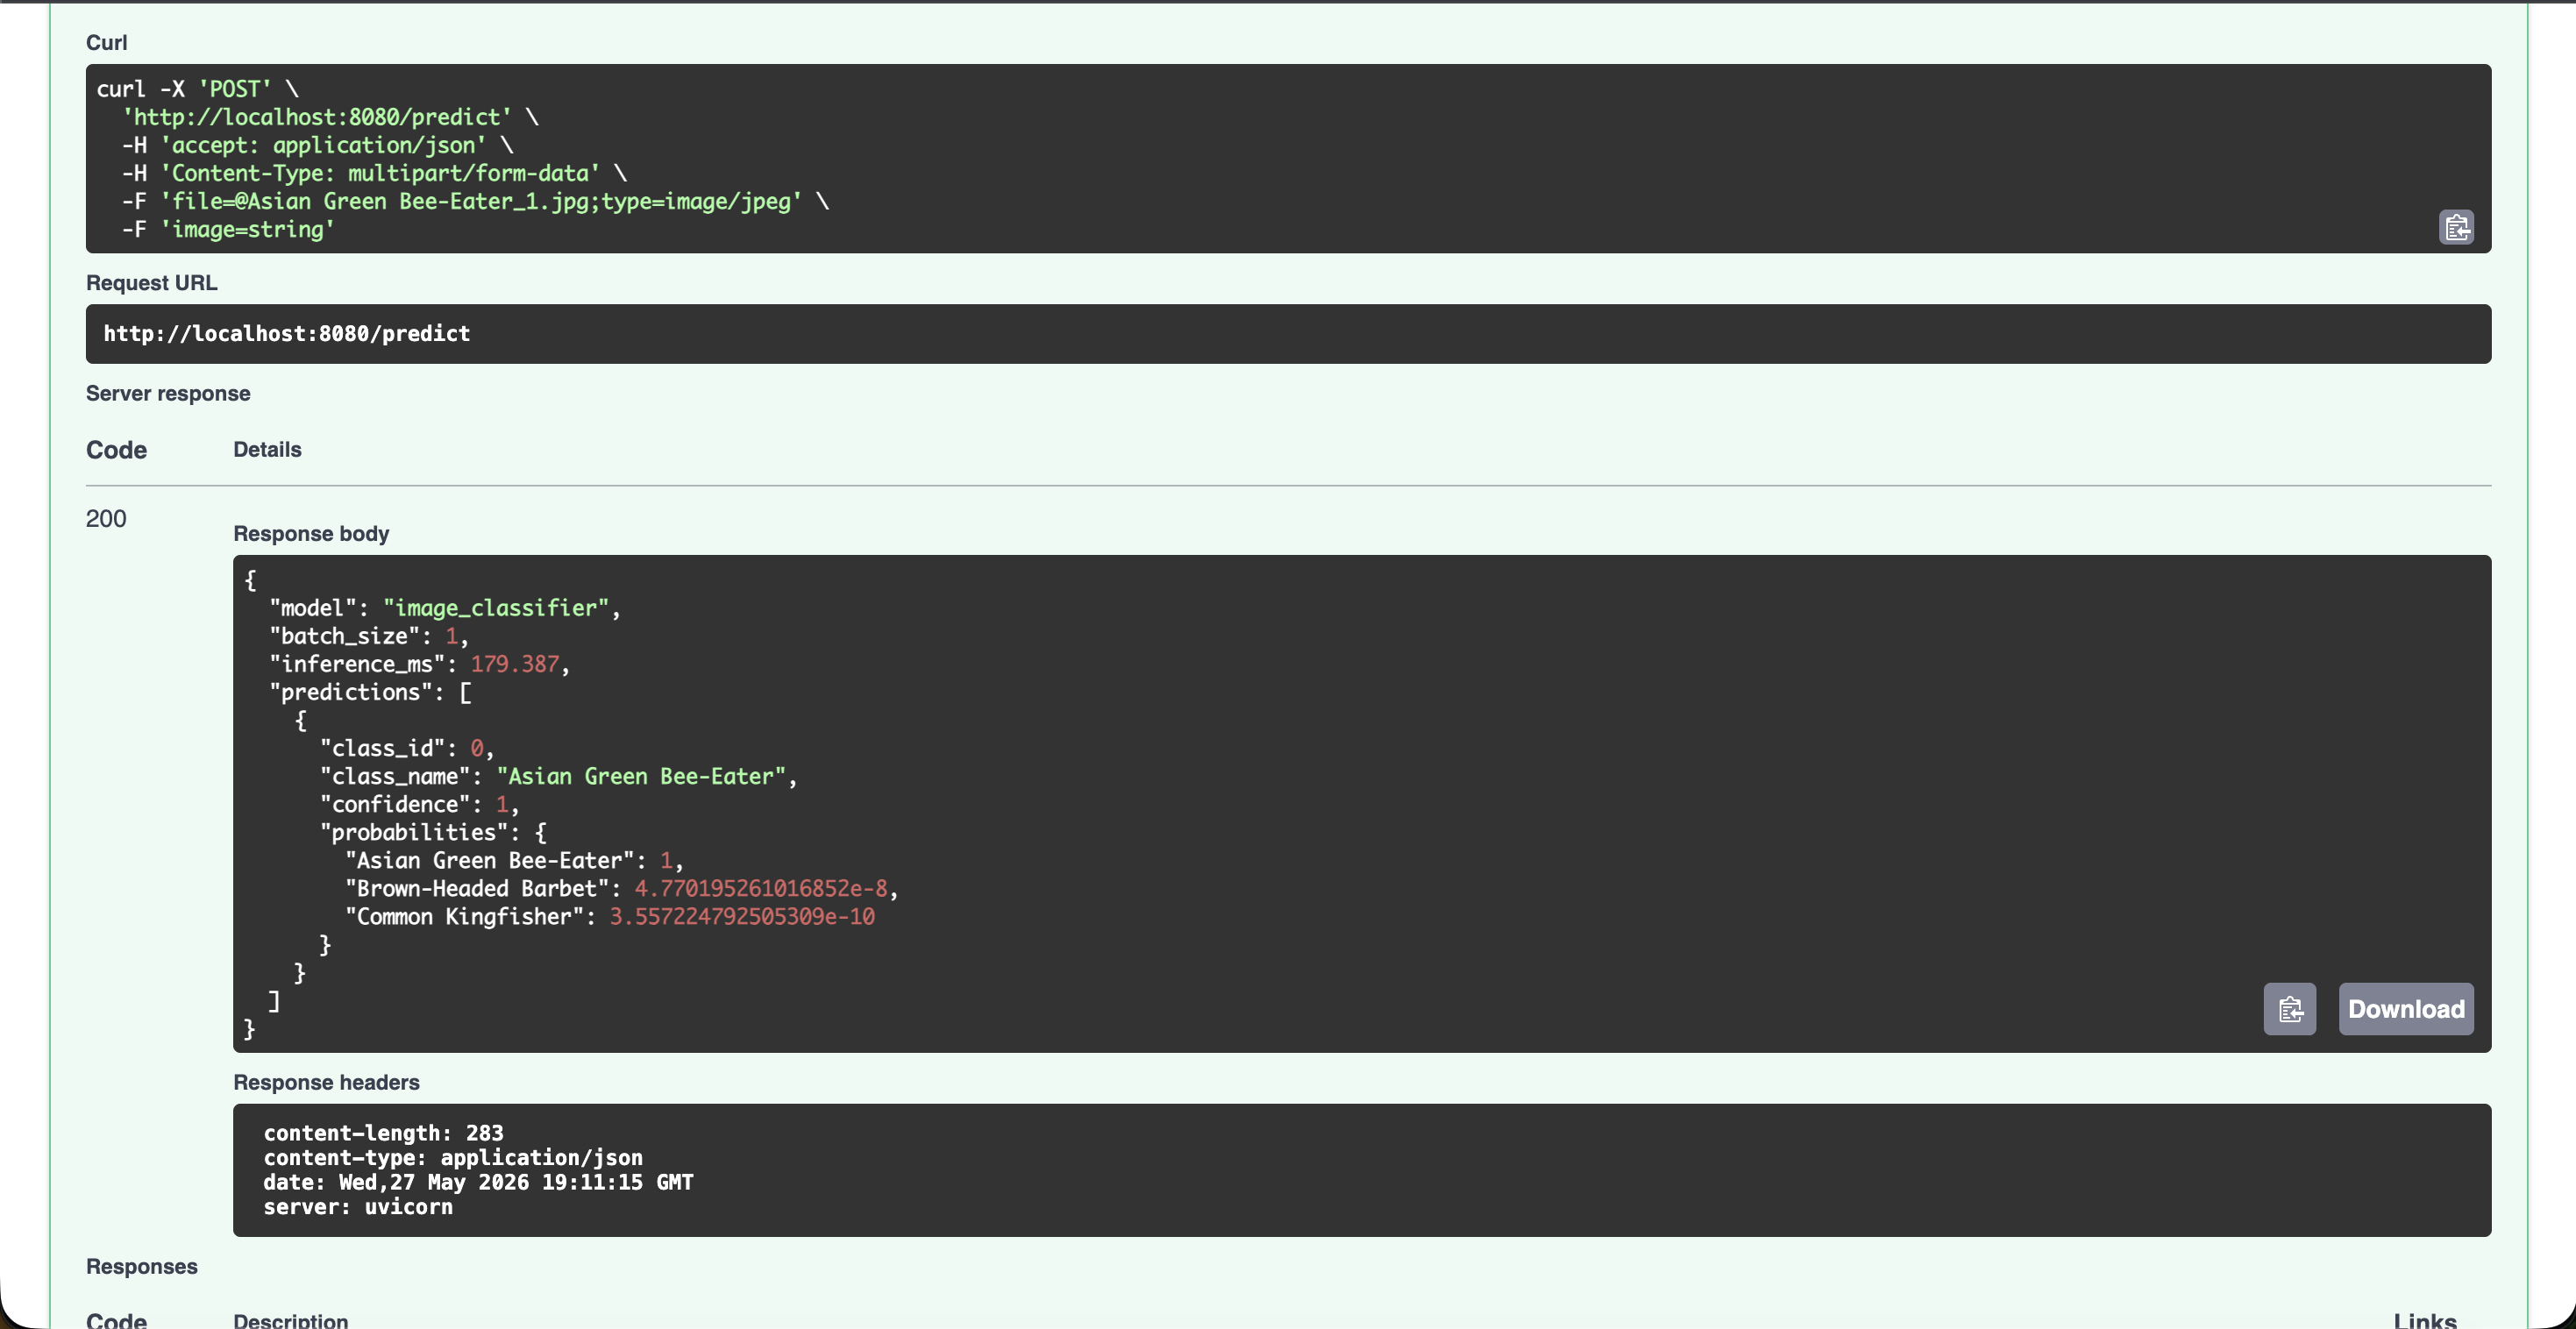

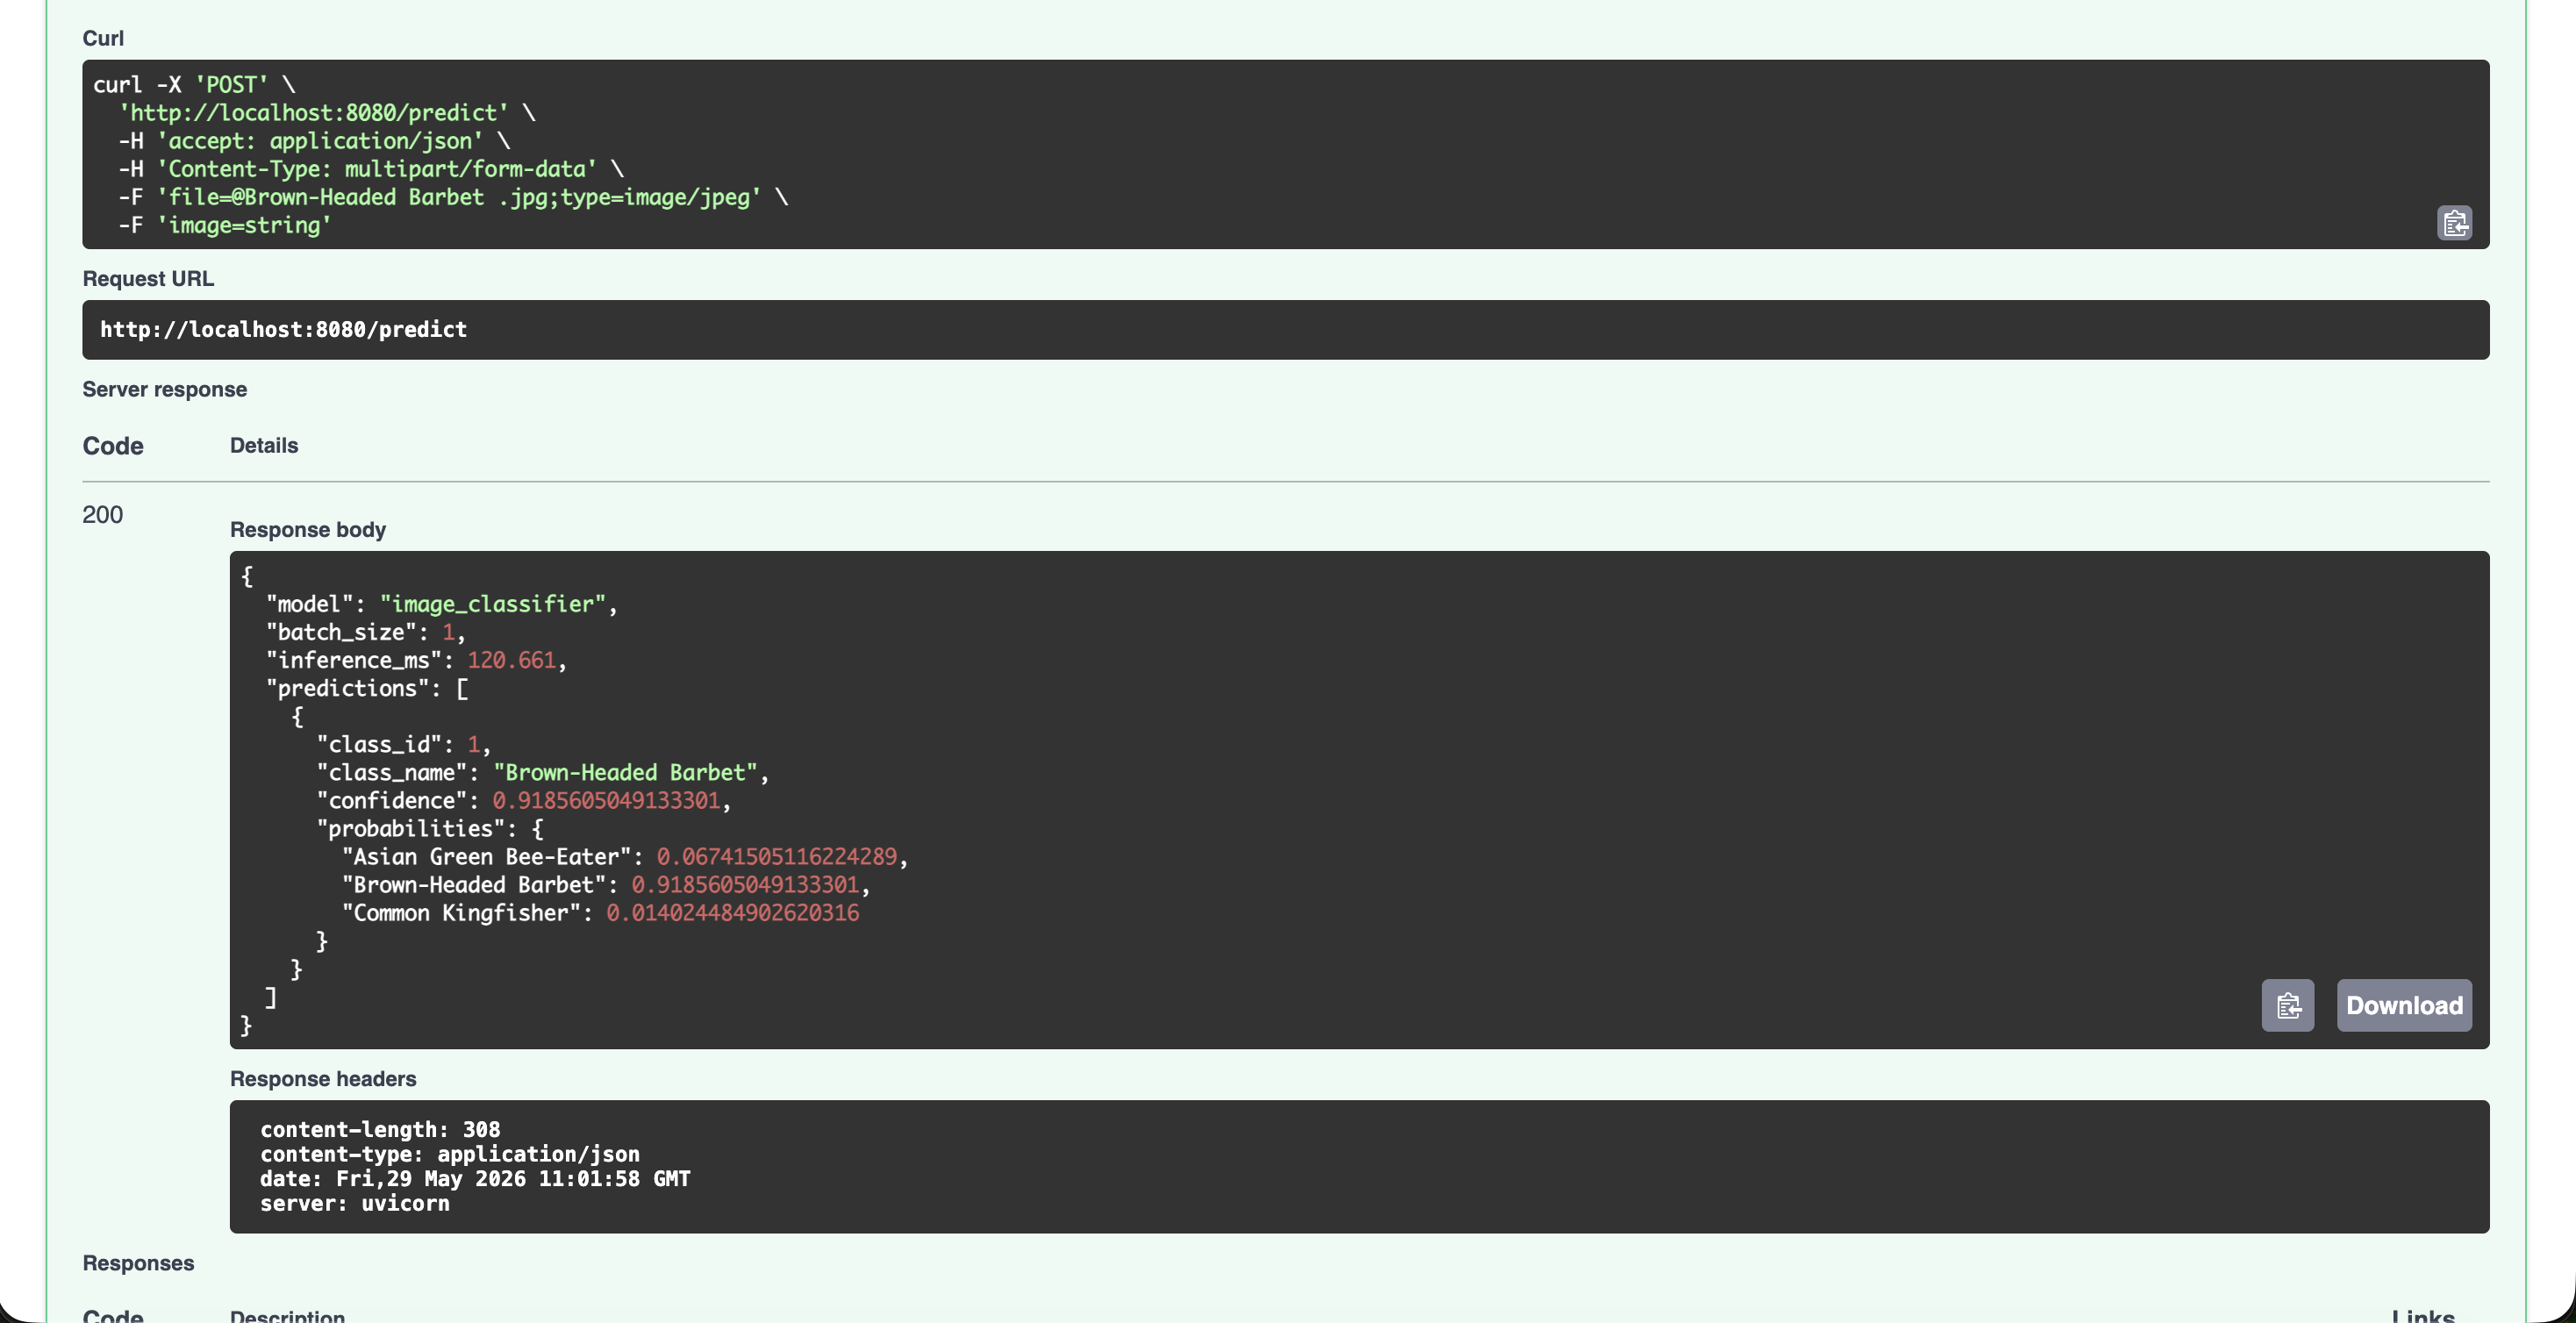

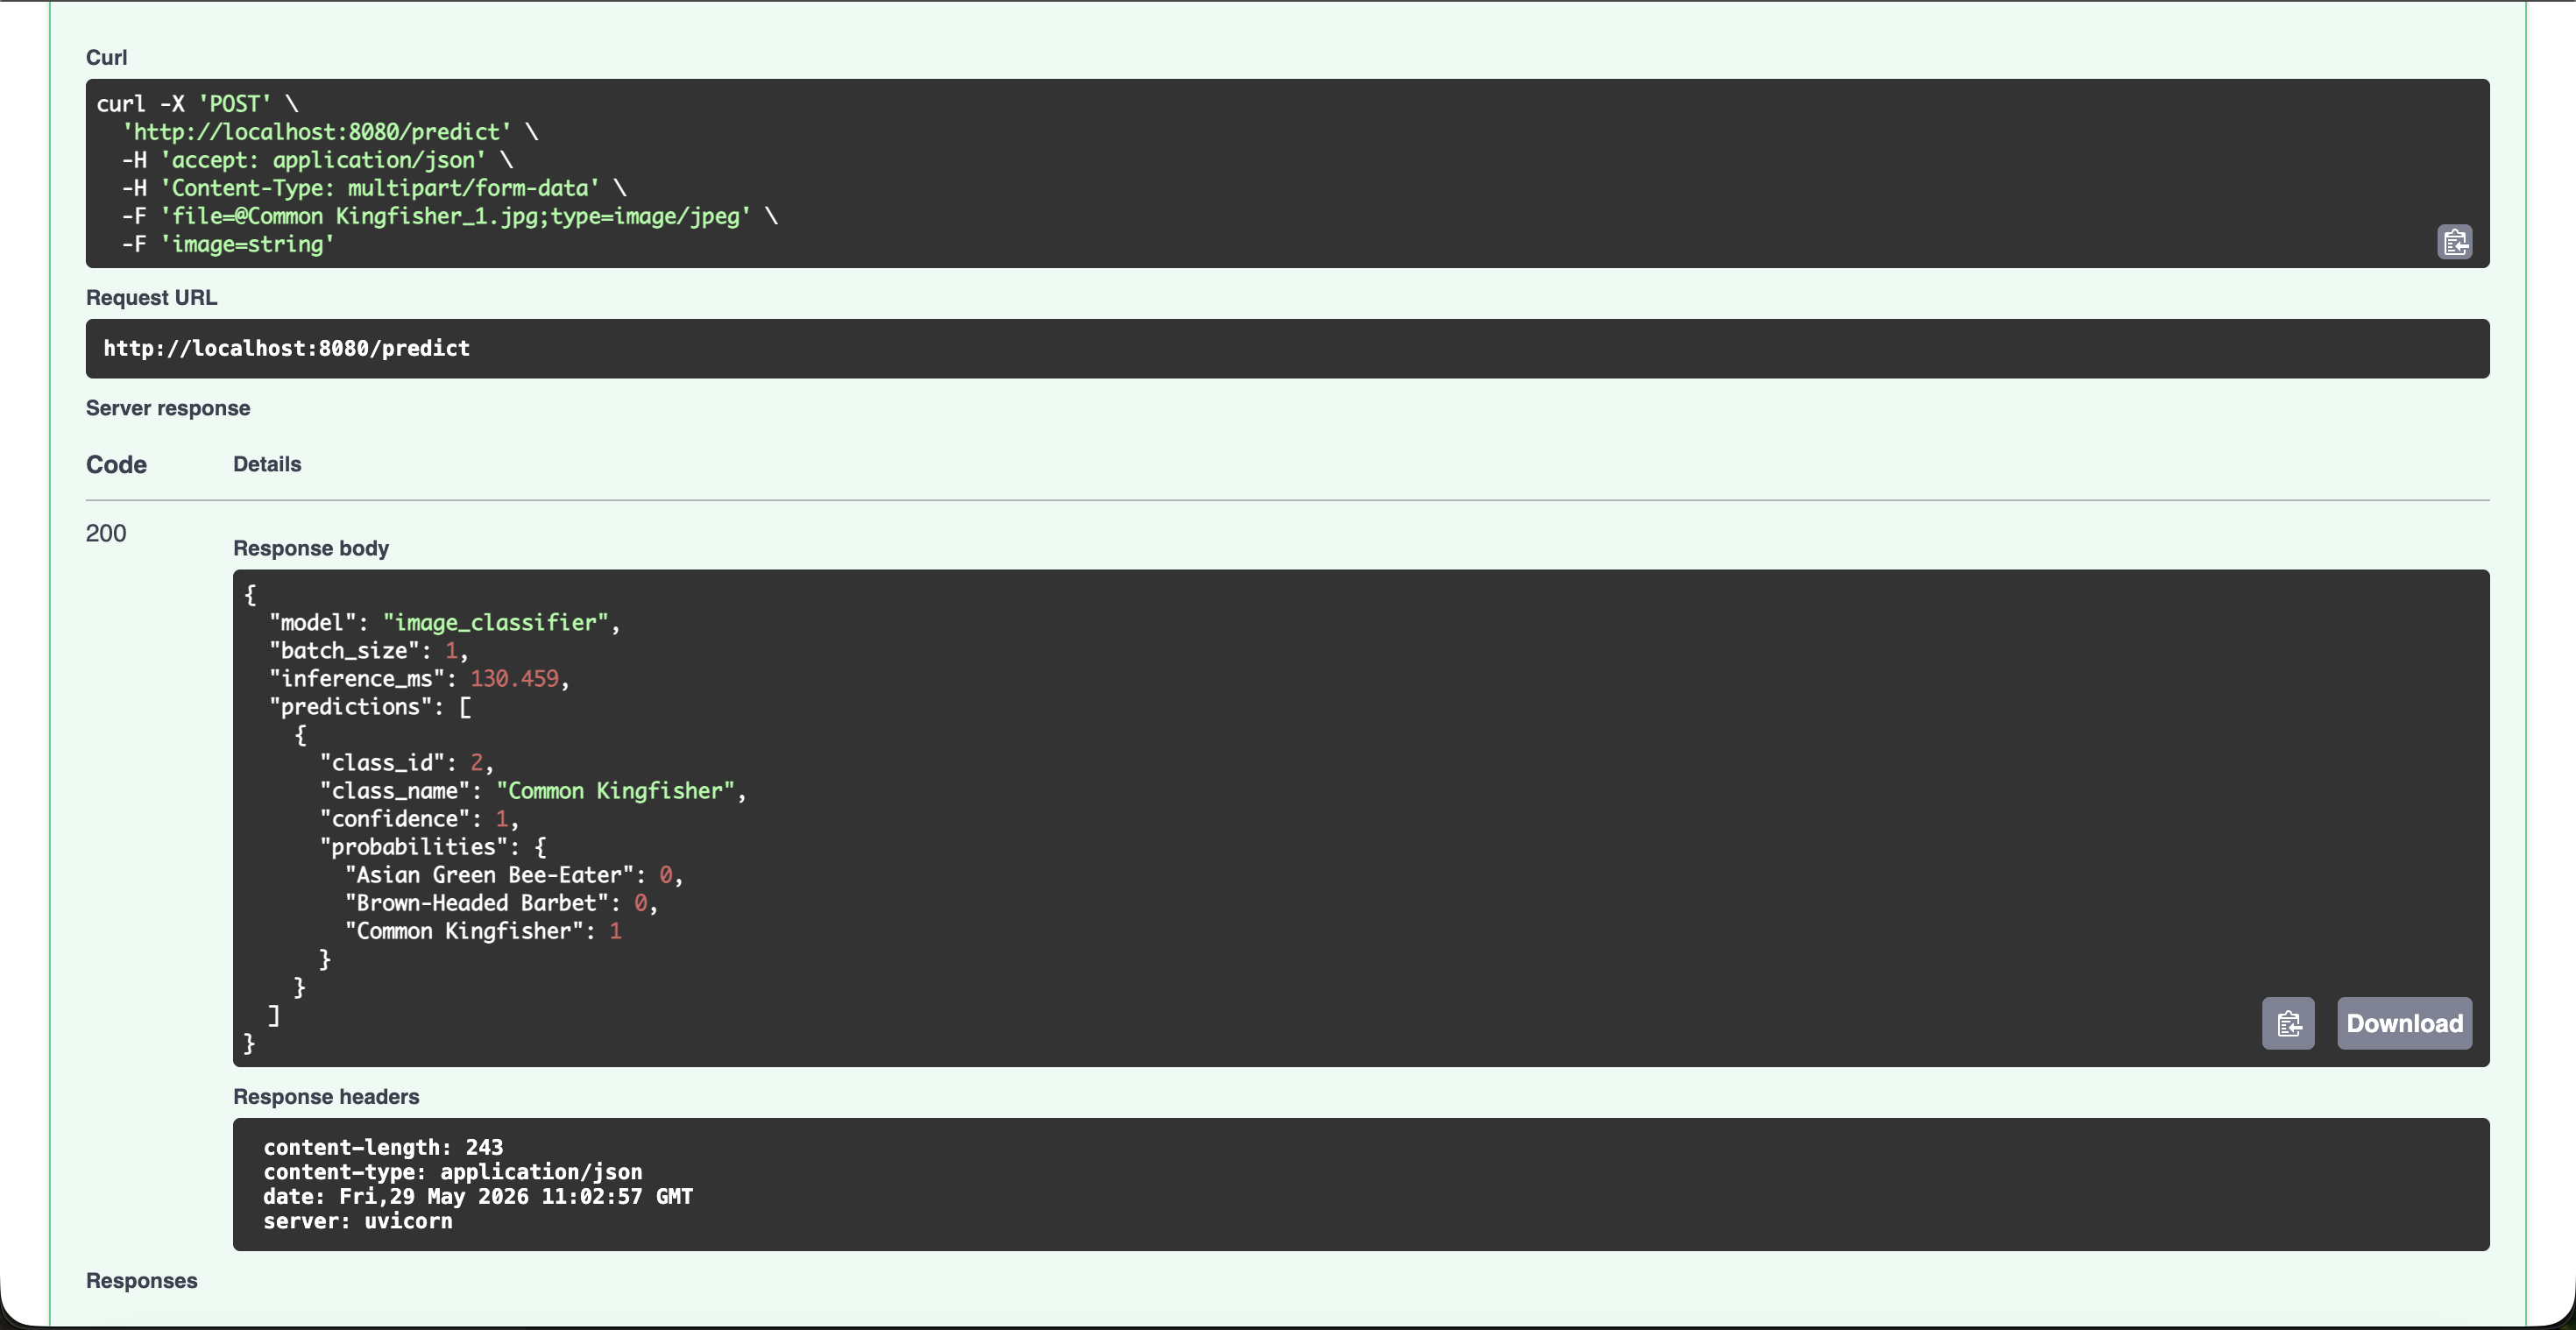

**Скриншот успешного запроса через Swagger UI**

---

## **Раздел 4. Настройка мониторинга**

### **Шаг 1. Вход в Grafana**

1. Откройте в браузере `http://localhost:3000`
2. Введите логин: `admin`, пароль: `admin`
3. При первом входе система предложит сменить пароль — можно пропустить (Skip)

---

### **Шаг 2. Проверка подключения Prometheus**

1. Перейдите в **Connections → Data sources** (левое меню)
2. Убедитесь, что Prometheus добавлен и статус **"Data source is working"**
3. Если нет — добавьте вручную:
   - **URL:** `http://prometheus:9090`
   - Нажмите **Save & Test**

---

### **Шаг 3. Создание дашборда**

1. Нажмите **Dashboards** (левое меню) → **New** → **New Dashboard**
2. Нажмите **Add visualization**
3. Выберите источник данных **Prometheus**

---

### **Шаг 4. Добавление панелей с метриками**

#### **Панель 1: Запросы в секунду (RPS)**

| Параметр | Значение |
|----------|----------|
| **Title** | Requests per Second |
| **Visualization** | Time series |
| **PromQL** | `rate(nv_inference_request_success{model="image_classifier"}[1m])` |



Для отображения успешных и неуспешных запросов на одном графике добавьте второй Query:

```promql
rate(nv_inference_request_failure{model="image_classifier"}[1m])
```

---

#### **Панель 2: Латентность инференса (p50, p95, p99)**

| Параметр | Значение |
|----------|----------|
| **Title** | Inference Latency |
| **Visualization** | Time series |
| **Unit** | microseconds (µs) или milliseconds (ms) |



Добавьте три Query:



**p50 (медиана):**

```promql
histogram_quantile(0.50,
  rate(nv_inference_request_duration_us_bucket{model="image_classifier"}[1m])
)
```

**p95:**

```promql
histogram_quantile(0.95,
  rate(nv_inference_request_duration_us_bucket{model="image_classifier"}[1m])
)
```

**p99:**

```promql
histogram_quantile(0.99,
  rate(nv_inference_request_duration_us_bucket{model="image_classifier"}[1m])
)
```

В настройках каждого Query задайте **Legend**: `p50`, `p95`, `p99` соответственно.

---

#### **Панель 3: Размер очереди запросов**

| Параметр | Значение |
|----------|----------|
| **Title** | Pending Requests (Queue) |
| **Visualization** | Time series или Stat |
| **PromQL** | `nv_inference_pending_request_count{model="image_classifier"}` |

---

#### **Панель 4: Счётчики запросов (успешные/неуспешные)**

| Параметр | Значение |
|----------|----------|
| **Title** | Total Requests |
| **Visualization** | Stat |



**Успешные запросы:**

```promql
nv_inference_request_success{model="image_classifier"}
```

**Неуспешные запросы:**

```promql
nv_inference_request_failure{model="image_classifier"}
```

---

#### **Панель 5 (опционально): Время в очереди**

| Параметр | Значение |
|----------|----------|
| **Title** | Queue Time |
| **Visualization** | Time series |
| **PromQL** | `rate(nv_inference_queue_duration_us_sum{model="image_classifier"}[1m]) / rate(nv_inference_queue_duration_us_count{model="image_classifier"}[1m])` |

---

### **Шаг 5. Настройка внешнего вида**

1. Для каждой панели нажмите на заголовок → **Edit**
2. В правой панели настройте:
   - **Panel options → Title** — название панели
   - **Standard options → Unit** — единицы измерения (например, `µs` для латентности)
   - **Standard options → Color scheme** — цветовая схема
3. Расположите панели на дашборде перетаскиванием

---

### **Шаг 6. Сохранение дашборда**

1. Нажмите иконку **Save dashboard** (💾) в верхнем правом углу
2. Введите название: `Triton Inference Monitoring`
3. Нажмите **Save**

---

### **Шаг 7. Экспорт в JSON**

1. Нажмите иконку **Share** (🔗) в верхнем правом углу
2. Перейдите на вкладку **Export**
3. Включите **Export for sharing externally**
4. Нажмите **Save to file**
5. Сохраните файл как `triton.json`
6. Поместите файл в папку `grafana/provisioning/dashboards/`

---

### **Основные метрики Triton для Prometheus**

| Метрика | Описание |
|---------|----------|
| `nv_inference_request_success` | Количество успешных запросов |
| `nv_inference_request_failure` | Количество неуспешных запросов |
| `nv_inference_count` | Общее количество инференсов |
| `nv_inference_request_duration_us` | Полная длительность запроса (мкс) |
| `nv_inference_queue_duration_us` | Время ожидания в очереди (мкс) |
| `nv_inference_compute_infer_duration_us` | Время выполнения инференса (мкс) |
| `nv_inference_pending_request_count` | Текущее количество запросов в очереди |

---

#### **Ответ:**

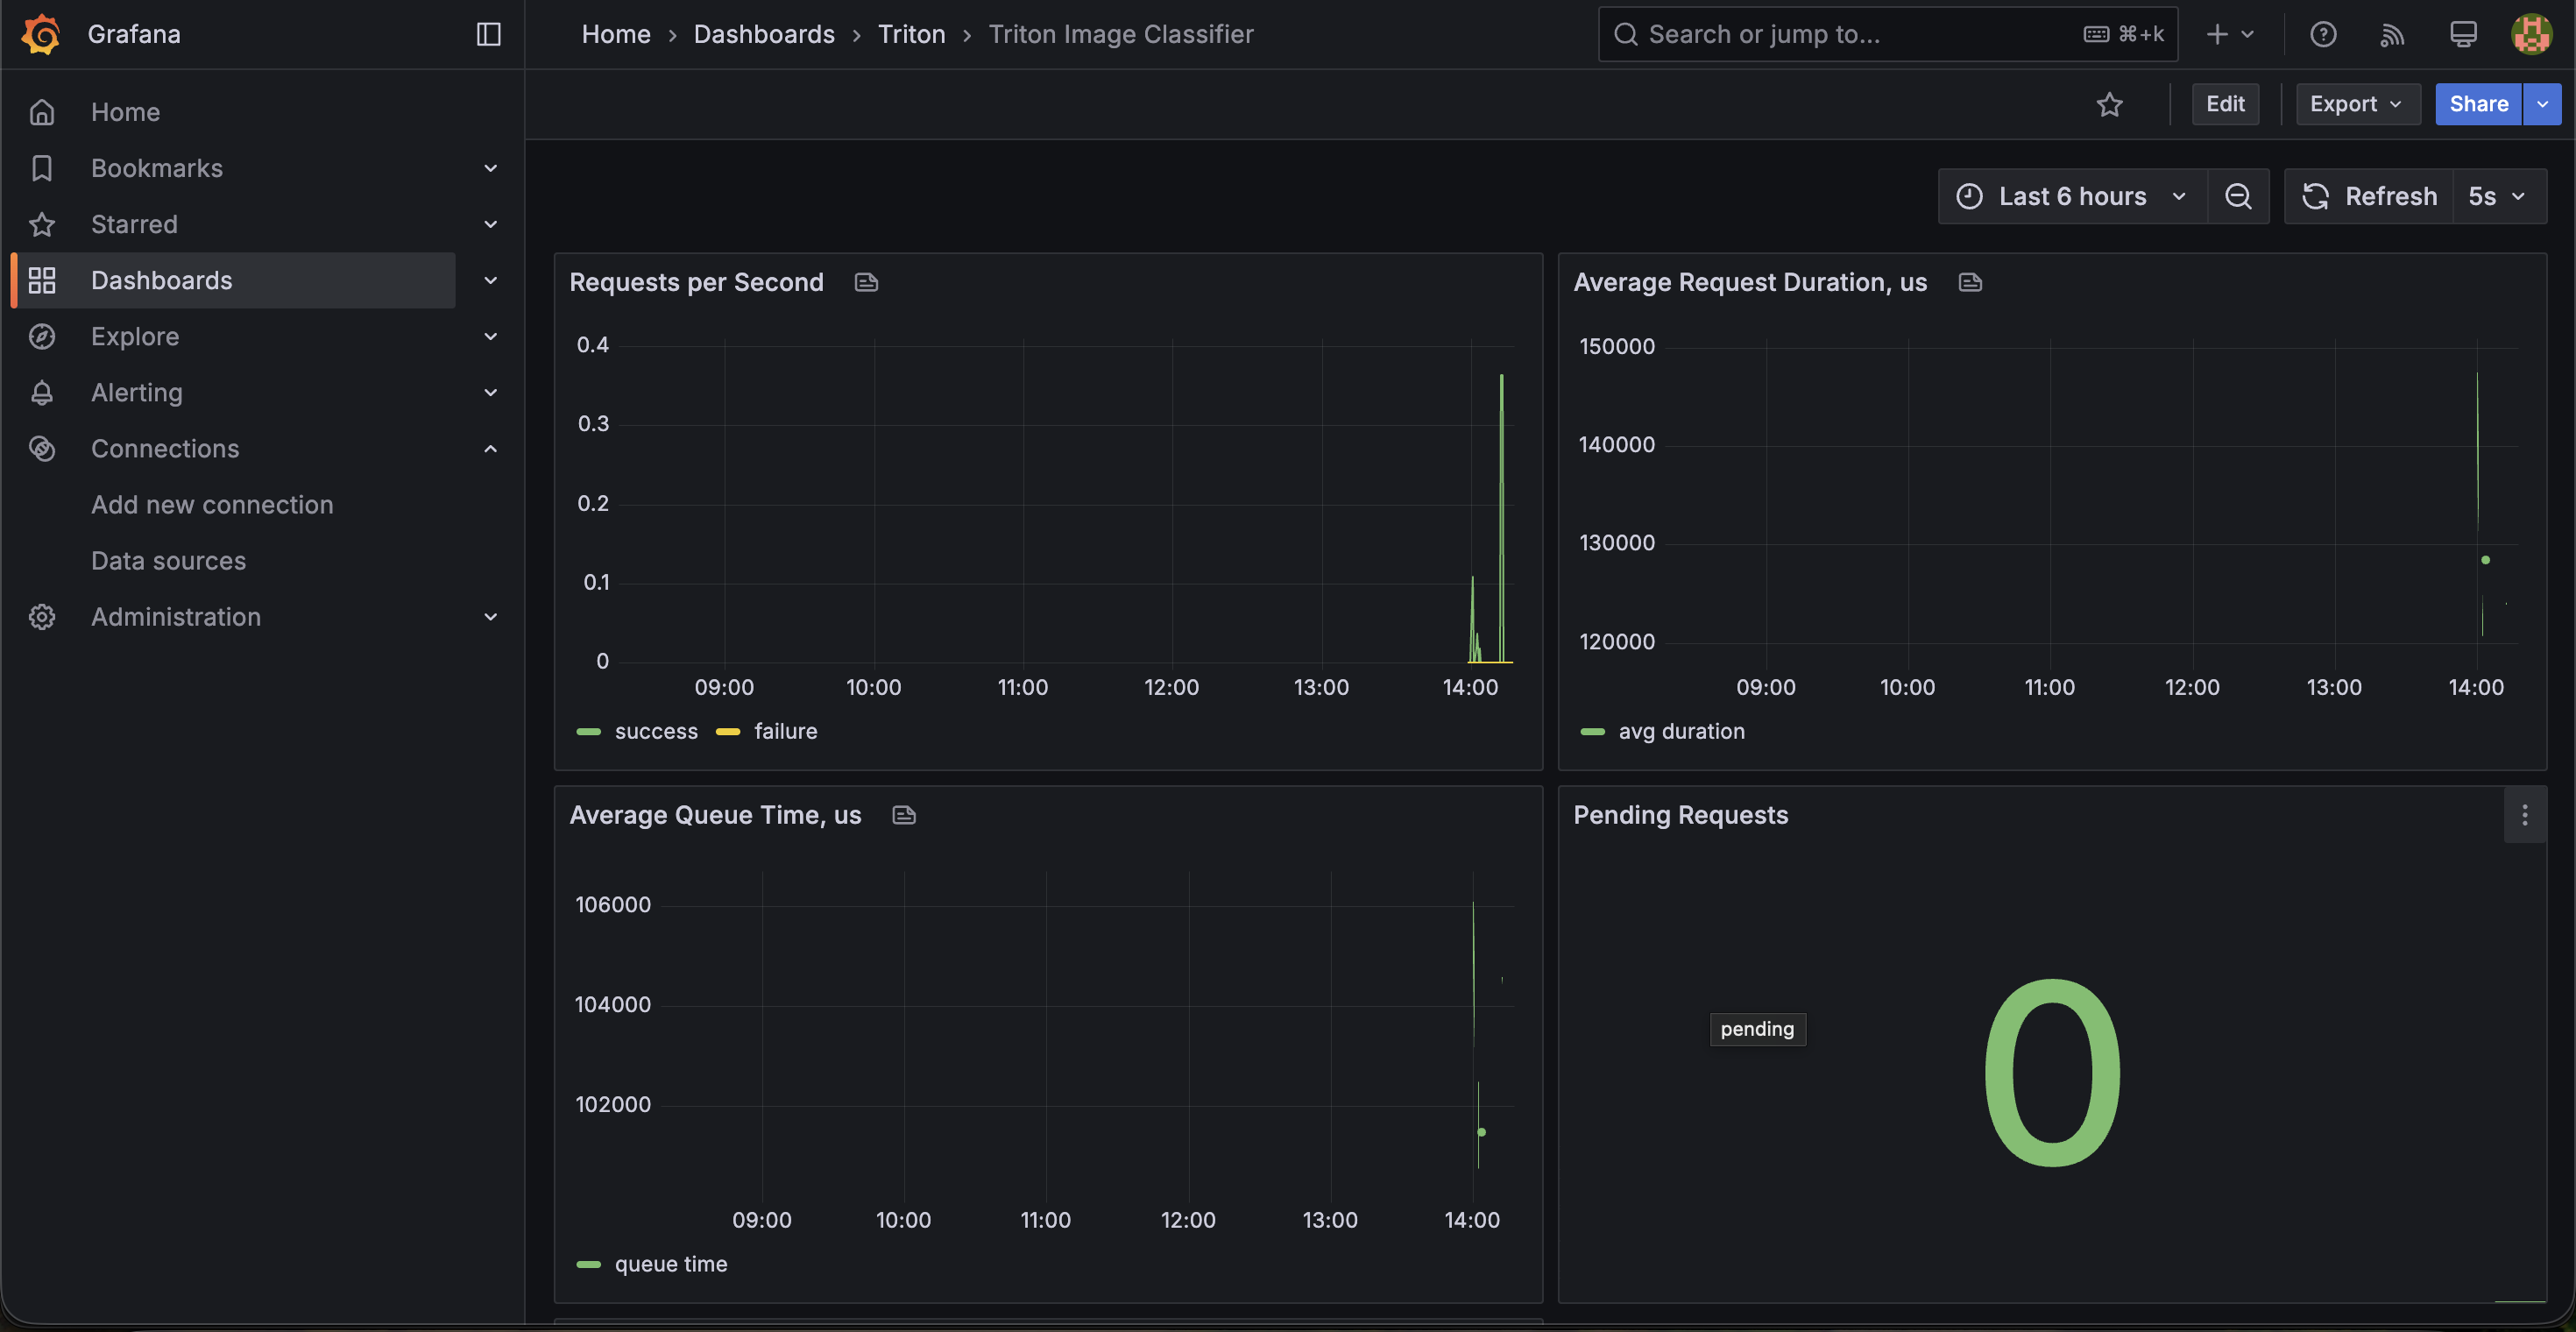

**Скриншот дашборда Grafana с метриками**



---

## **Раздел 5. Нагрузочное тестирование**

1. Написать Python-скрипт для нагрузочного тестирования:
   - Отправка 1000+ запросов с использованием `asyncio` / `aiohttp` или `concurrent.futures`
   - Измерение среднего времени ответа, p95, p99
   - Подсчёт успешных и неуспешных запросов
   - Расчёт throughput (запросов в секунду)

<details> <summary>Пример скрипта нагрузочного тестирования</summary>


```python
"""
Скрипт нагрузочного тестирования API
"""

import asyncio
import aiohttp
import time
import numpy as np
from PIL import Image
import io
import base64


# === НАСТРОЙКИ ===
API_URL = "http://localhost:8080/predict"
TOTAL_REQUESTS = 1000
CONCURRENT = 50


def generate_test_image() -> str: # Замените формат входных данных под вашу модель и бекенд
    """Генерирует случайное изображение в base64"""
    img = Image.fromarray(np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8))
    buffer = io.BytesIO()
    img.save(buffer, format='PNG')
    return base64.b64encode(buffer.getvalue()).decode()


async def send_request(session, semaphore, payload):
    """Отправляет один запрос"""
    async with semaphore:
        start = time.perf_counter()
        try:
            async with session.post(API_URL, json=payload, timeout=aiohttp.ClientTimeout(total=30)) as resp:
                await resp.json()
                return resp.status == 200, time.perf_counter() - start
        except:
            return False, time.perf_counter() - start


async def main():
    print(f"🚀 Запуск теста: {TOTAL_REQUESTS} запросов, {CONCURRENT} параллельных\n")
    
    payload = {"image": generate_test_image()}
    semaphore = asyncio.Semaphore(CONCURRENT)
    
    async with aiohttp.ClientSession() as session:
        # Прогрев
        await asyncio.gather(*[send_request(session, semaphore, payload) for _ in range(5)])
        
        # Основной тест
        start_time = time.perf_counter()
        results = await asyncio.gather(*[send_request(session, semaphore, payload) for _ in range(TOTAL_REQUESTS)])
        total_time = time.perf_counter() - start_time
    
    # Подсчёт результатов
    successful = [r[1] for r in results if r[0]]
    failed = len(results) - len(successful)
    
    # Вывод
    print(f"📊 РЕЗУЛЬТАТЫ")
    print(f"{'='*40}")
    print(f"Успешных:    {len(successful)}/{TOTAL_REQUESTS} ({len(successful)/TOTAL_REQUESTS*100:.1f}%)")
    print(f"Неуспешных:  {failed}")
    print(f"Время:       {total_time:.2f} сек")
    print(f"\n⚡ Throughput: {TOTAL_REQUESTS/total_time:.2f} RPS")
    print(f"\n⏱️  Латентность (мс):")
    print(f"   Avg:  {np.mean(successful)*1000:.2f}")
    print(f"   p50:  {np.percentile(successful, 50)*1000:.2f}")
    print(f"   p95:  {np.percentile(successful, 95)*1000:.2f}")
    print(f"   p99:  {np.percentile(successful, 99)*1000:.2f}")


if __name__ == "__main__":
    asyncio.run(main())
```



2. Провести тестирование с разными конфигурациями Dynamic Batching:



| Конфигурация | preferred_batch_size | max_queue_delay_microseconds |
|--------------|---------------------|------------------------------|
| Без батчинга | — | — |
| Малый батч | [2, 4] | 50000 |
| Средний батч | [4, 8, 16] | 100000 |
| Большой батч | [8, 16, 32] | 200000 |

3. Заполнить таблицу результатов:



| Конфигурация | Avg Latency (ms) | P95 (ms) | P99 (ms) | Throughput (RPS) |
|--------------|------------------|----------|----------|------------------|
| Без батчинга | 743.19 | 895.79 | 925.35 | 65.43 |
| Малый батч | 387.30 | 494.82 | 538.59 | 126.94 |
| Средний батч | 378.23 | 453.48 | 502.01 | 129.62 |
| Большой батч | 377.22 | 479.11 | 525.50 | 130.34 |







4. Построить графики сравнения конфигураций


,configuration,preferred_batch_size,max_queue_delay_microseconds,avg_latency_ms,p95_ms,p99_ms,throughput_rps
0,Без батчинга,-,-,743.19,895.79,925.35,65.43
1,Малый батч,"[2, 4]",50000,387.30,494.82,538.59,126.94
2,Средний батч,"[4, 8, 16]",100000,378.23,453.48,502.01,129.62
3,Большой батч,"[8, 16, 32]",200000,377.22,479.11,525.50,130.34


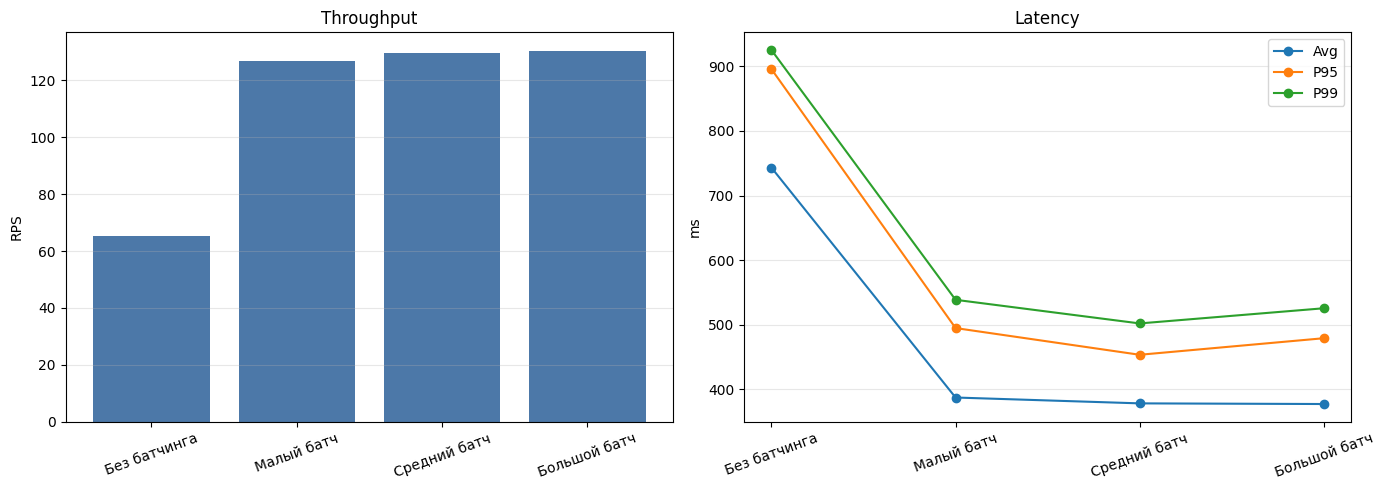

In [1]:
# Ваш код
import pandas as pd
import matplotlib.pyplot as plt

results = [
    {
        "configuration": "Без батчинга",
        "preferred_batch_size": "-",
        "max_queue_delay_microseconds": "-",
        "avg_latency_ms": 743.19,
        "p95_ms": 895.79,
        "p99_ms": 925.35,
        "throughput_rps": 65.43,
    },
    {
        "configuration": "Малый батч",
        "preferred_batch_size": "[2, 4]",
        "max_queue_delay_microseconds": 50000,
        "avg_latency_ms": 387.30,
        "p95_ms": 494.82,
        "p99_ms": 538.59,
        "throughput_rps": 126.94,
    },
    {
        "configuration": "Средний батч",
        "preferred_batch_size": "[4, 8, 16]",
        "max_queue_delay_microseconds": 100000,
        "avg_latency_ms": 378.23,
        "p95_ms": 453.48,
        "p99_ms": 502.01,
        "throughput_rps": 129.62,
    },
    {
        "configuration": "Большой батч",
        "preferred_batch_size": "[8, 16, 32]",
        "max_queue_delay_microseconds": 200000,
        "avg_latency_ms": 377.22,
        "p95_ms": 479.11,
        "p99_ms": 525.50,
        "throughput_rps": 130.34,
    },
]

df = pd.DataFrame(results)
display(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df["configuration"], df["throughput_rps"], color="#4C78A8")
axes[0].set_title("Throughput")
axes[0].set_ylabel("RPS")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(df["configuration"], df["avg_latency_ms"], marker="o", label="Avg")
axes[1].plot(df["configuration"], df["p95_ms"], marker="o", label="P95")
axes[1].plot(df["configuration"], df["p99_ms"], marker="o", label="P99")
axes[1].set_title("Latency")
axes[1].set_ylabel("ms")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


5. Сделать выводы о влиянии Dynamic Batching на производительность

#### **Ответ:**

Для нагрузочного тестирования был добавлен скрипт `benchmark_dynamic_batching.py`. Он последовательно переключает `config.pbtxt`, перезапускает Triton и FastAPI, отправляет 1000 запросов к `/predict` с параллельностью 50 и сохраняет результаты в папку `results`.

Команда запуска теста:

```bash
python3 -u benchmark_dynamic_batching.py \
  --image "../../ПР-3/birds_test/Common Kingfisher_1.jpg" \
  --requests 1000 \
  --concurrency 50 \
  --warmup 20 \
  --mode all \
  --restore medium \
  --results-dir results
```

Результаты сохранены в файлы:

```text
results/dynamic_batching_results.json
results/dynamic_batching_results.md
results/dynamic_batching_comparison.svg
```

| Конфигурация | preferred_batch_size | max_queue_delay_microseconds | Avg Latency (ms) | P95 (ms) | P99 (ms) | Throughput (RPS) | Успешно |
|---|---|---:|---:|---:|---:|---:|---:|
| Без батчинга | - | - | 743.19 | 895.79 | 925.35 | 65.43 | 1000/1000 |
| Малый батч | [2, 4] | 50000 | 387.30 | 494.82 | 538.59 | 126.94 | 1000/1000 |
| Средний батч | [4, 8, 16] | 100000 | 378.23 | 453.48 | 502.01 | 129.62 | 1000/1000 |
| Большой батч | [8, 16, 32] | 200000 | 377.22 | 479.11 | 525.50 | 130.34 | 1000/1000 |

Перед финальным прогоном API был исправлен: блокирующий вызов Triton вынесен в threadpool через `run_in_threadpool`. Без этого `async` endpoint частично сериализовал запросы и искажал результат dynamic batching.

Вывод: dynamic batching заметно повысил производительность сервиса. Throughput вырос с 65.43 RPS без batching до 126.94-130.34 RPS с batching, а средняя latency снизилась с 743.19 ms до примерно 377-387 ms. Лучший результат по P95 показала средняя конфигурация `[4, 8, 16]` с задержкой очереди `100000` microseconds. Большая конфигурация дала максимальный throughput, но немного худшие P95/P99, поэтому для баланса latency и throughput выбран средний batch.

## **Раздел 6. Интеграция со Streamlit (опционально)**

1. Адаптировать Streamlit-приложение из практической работы №10 для работы с новым API
2. Добавить отображение времени инференса
3. Развернуть локально и проверить работу

#### **Ответ:**

**Скриншот Streamlit с результатом инференса**


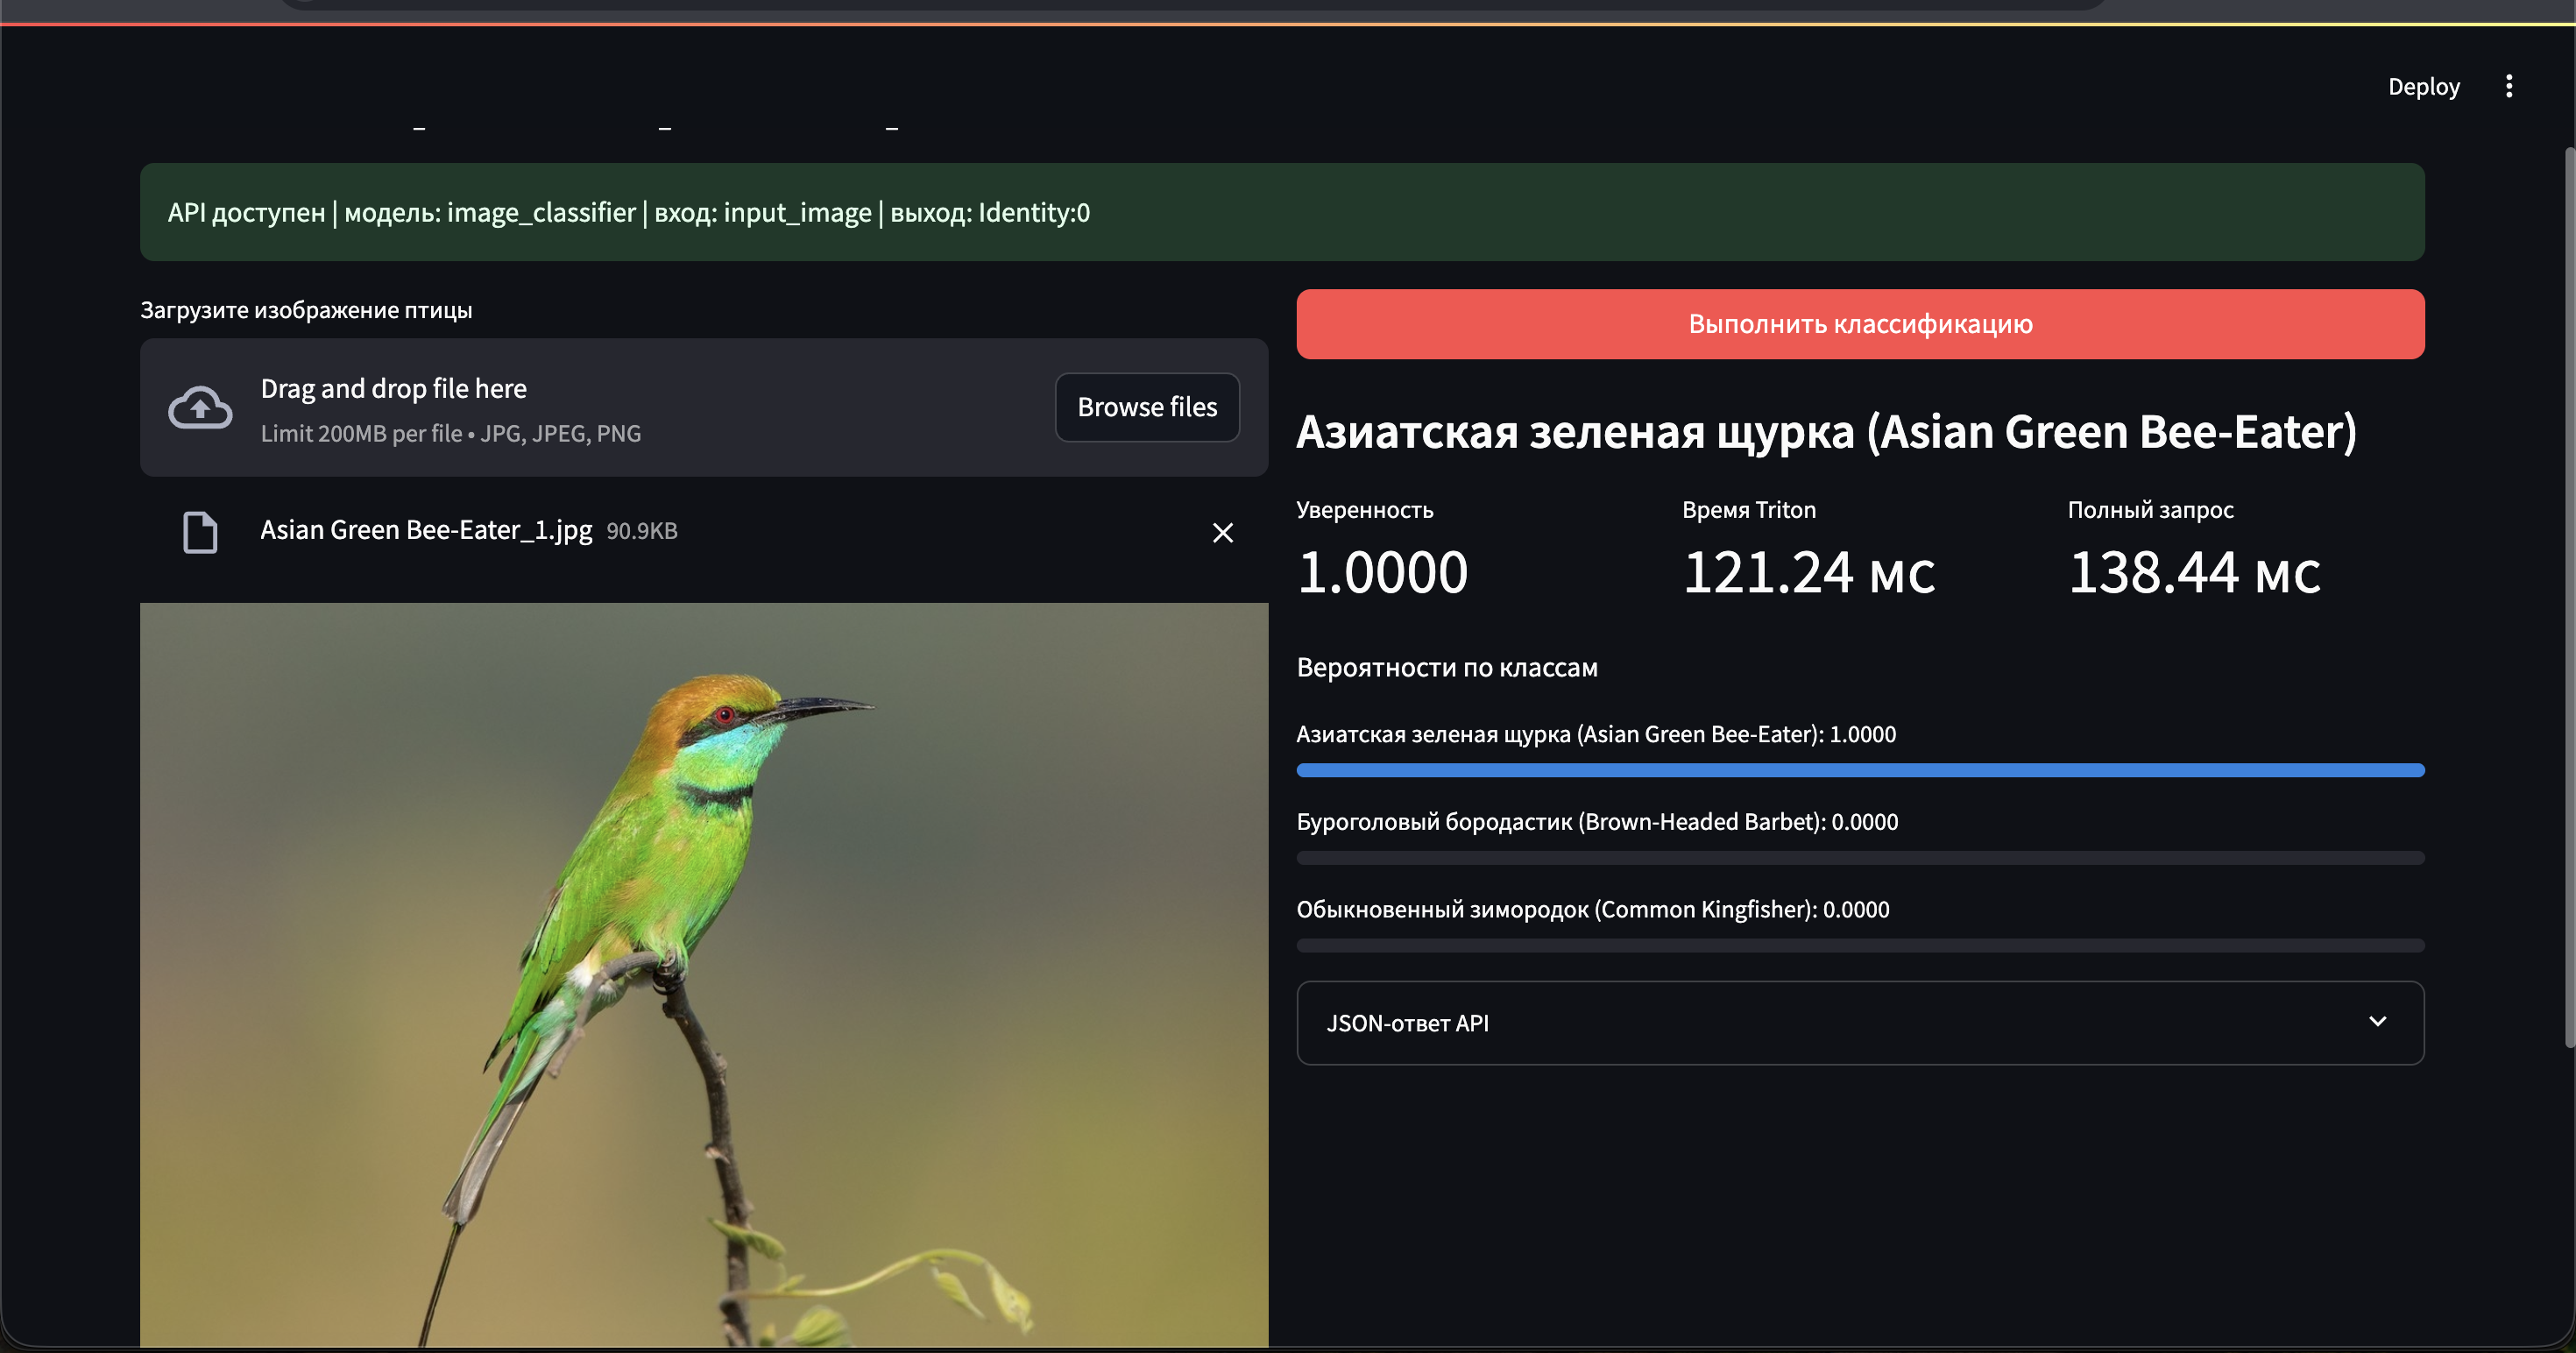

---

## **Раздел 7. Документация и публикация**

1. Создать GitHub-репозиторий с полной структурой проекта
2. Написать README.md с:
   - Описанием архитектуры решения
   - Инструкцией по запуску
   - Описанием API endpoints
   - Результатами нагрузочного тестирования
   - Скриншотами Grafana-дашборда
   - Выводами о производительности

#### **Ответ:**

**ВАША ССЫЛКА НА GITHUB-РЕПОЗИТОРИЙ** https://github.com/Koroteika/triton-classification

---

**Репозиторий должен быть полностью воспроизводим: после клонирования проект должен запускаться командой**





```bash
git clone <ссылка на ваш репозиторий>
cd <имя репозитория>
docker-compose up -d
```



**чтобы я мог проверить работу решения.**


**Пример:** https://github.com/Alexandre77777/triton-ml-project

---

## **Полезные материалы**

- [Документация NVIDIA Triton](https://docs.nvidia.com/deeplearning/triton-inference-server/)
- [tf2onnx](https://github.com/onnx/tensorflow-onnx)
- [Triton Model Configuration](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/user_guide/model_configuration.html)